In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/insurance.csv')

In [ ]:
#Let us eye ball the data and get the descriptives of the data
df.head()


,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000


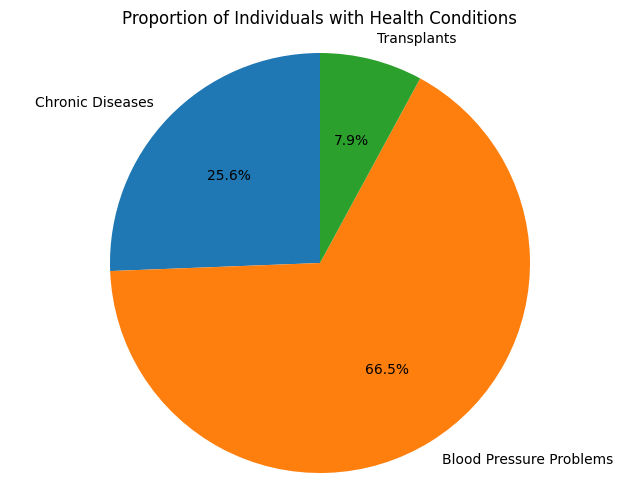

In [ ]:
# @title Proportion of Individuals with Health Conditions

import matplotlib.pyplot as plt

chronic_count = df['AnyChronicDiseases'].sum()
bp_count = df['BloodPressureProblems'].sum()
transplant_count = df['AnyTransplants'].sum()

labels = ['Chronic Diseases', 'Blood Pressure Problems', 'Transplants']
sizes = [chronic_count, bp_count, transplant_count]

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Individuals with Health Conditions')
_ = plt.axis('equal')

In [ ]:
# prompt: Using dataframe df: get statistics of dataframe

# Generate descriptive statistics for the dataframe
df.describe(include='all')


,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
count,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000
mean,41.745436,0.419878,0.468560,0.055781,0.180527,168.182556,76.950304,0.215010,0.117647,0.667343,24336.713996
std,13.963371,0.493789,0.499264,0.229615,0.384821,10.098155,14.265096,0.411038,0.322353,0.749205,6248.184382
min,18.000000,0.000000,0.000000,0.000000,0.000000,145.000000,51.000000,0.000000,0.000000,0.000000,15000.000000
25%,30.000000,0.000000,0.000000,0.000000,0.000000,161.000000,67.000000,0.000000,0.000000,0.000000,21000.000000
50%,42.000000,0.000000,0.000000,0.000000,0.000000,168.000000,75.000000,0.000000,0.000000,1.000000,23000.000000
75%,53.000000,1.000000,1.000000,0.000000,0.000000,176.000000,87.000000,0.000000,0.000000,1.000000,28000.000000
max,66.000000,1.000000,1.000000,1.000000,1.000000,188.000000,132.000000,1.000000,1.000000,3.000000,40000.000000


In [ ]:
df.isnull().sum()

,0
Age,0
Diabetes,0
BloodPressureProblems,0
AnyTransplants,0
AnyChronicDiseases,0
Height,0
Weight,0
KnownAllergies,0
HistoryOfCancerInFamily,0
NumberOfMajorSurgeries,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      986 non-null    int64
 1   Diabetes                 986 non-null    int64
 2   BloodPressureProblems    986 non-null    int64
 3   AnyTransplants           986 non-null    int64
 4   AnyChronicDiseases       986 non-null    int64
 5   Height                   986 non-null    int64
 6   Weight                   986 non-null    int64
 7   KnownAllergies           986 non-null    int64
 8   HistoryOfCancerInFamily  986 non-null    int64
 9   NumberOfMajorSurgeries   986 non-null    int64
 10  PremiumPrice             986 non-null    int64
dtypes: int64(11)
memory usage: 84.9 KB


In [ ]:
#We will look into the data set and check cardinality of each field in data set
for col in df.columns:
  print(f'{col}: {df[col].nunique()}')

Age: 49
Diabetes: 2
BloodPressureProblems: 2
AnyTransplants: 2
AnyChronicDiseases: 2
Height: 44
Weight: 74
KnownAllergies: 2
HistoryOfCancerInFamily: 2
NumberOfMajorSurgeries: 4
PremiumPrice: 24


In [ ]:
df.shape

(986, 11)

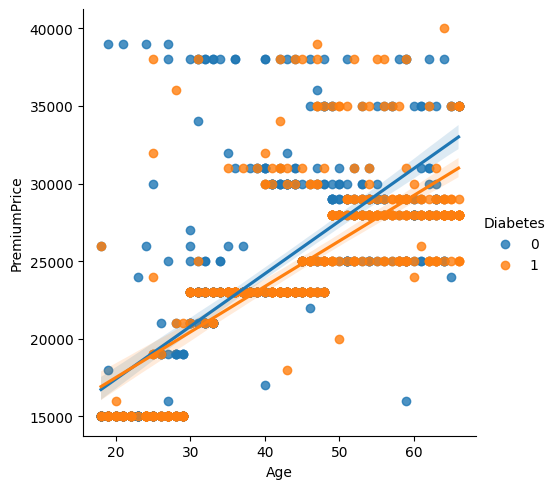

In [ ]:
#We will see how Age interacts with PremiumPrice with Diabetes as hue
import seaborn as sns
sns.lmplot(x='Age', y='PremiumPrice', data=df, hue='Diabetes')


##The Trend:

Overall: You can see an upward trend, suggesting that as Age increases, PremiumPrice tends to increase as well. This is pretty intuitive in insurance contexts as older individuals often have higher healthcare costs.
Diabetes Effect: Notice how the regression lines for individuals with and without diabetes have different slopes and intercepts. This indicates that Diabetes status has an impact on the relationship between Age and PremiumPrice.
Steeper Slope for Diabetes: The regression line for individuals with diabetes generally has a steeper slope, implying that their PremiumPrice increases more rapidly with age compared to those without diabetes.

##Interpretation:

The plot suggests a clear positive correlation between age and premium price, meaning as age increases, so does the premium price.
Having diabetes further accentuates this effect, with individuals with diabetes experiencing even higher premium prices as they age.
The difference in slopes highlights the impact of diabetes on insurance premiums. Insurers likely view diabetes as a significant risk factor, leading to higher premiums for affected individuals.

<ipython-input-12-ca19c0cd1da1>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Age_bin', y='PremiumPrice', data=df, palette='Set3')


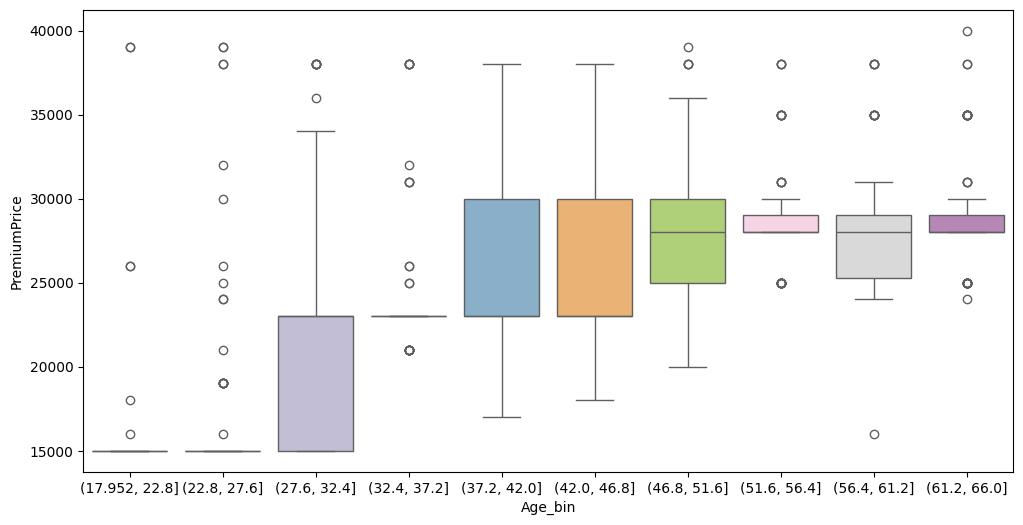

In [ ]:
# We will create Age bin with 10 bins with boxplot for PremiumPRice with different color
df['Age_bin'] = pd.cut(df['Age'], bins=10)
plt.figure(figsize=(12, 6))  # Adjust the width (12) as needed
sns.boxplot(x='Age_bin', y='PremiumPrice', data=df, palette='Set3')
plt.show()

## We could see the heavy skew in in later Age bin. We could also see that there is heavy skew.

We also see that as age progresses the PremiumPrice is also going up

Text(0.5, 1.0, 'Correlation Heatmap')

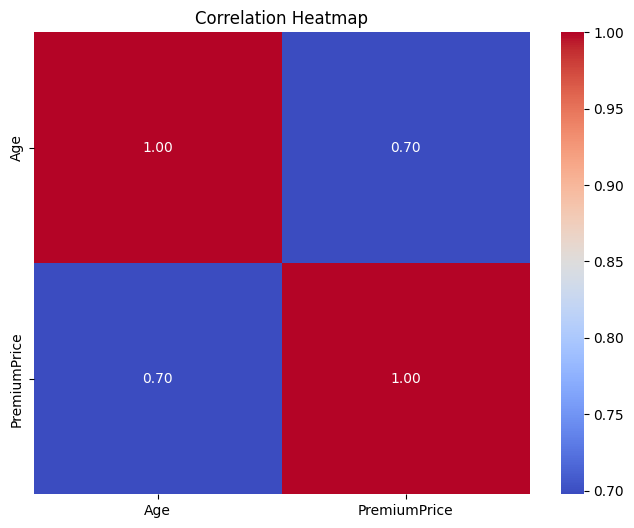

In [ ]:
#We will generate heatmap with Age and PRemiumPrice correlation
corr_matrix = df[['Age', 'PremiumPrice']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

## Let us perform the Hypothesis testing against PremiumPRice field

Kruskal-Wallis test for Diabetes: p-value = 0.006478335766833227
Kruskal-Wallis test for BloodPressureProblems: p-value = 3.080154619084556e-08
Kruskal-Wallis test for AnyTransplants: p-value = 9.226316721895476e-12
Kruskal-Wallis test for AnyChronicDiseases: p-value = 2.2594857005870487e-11


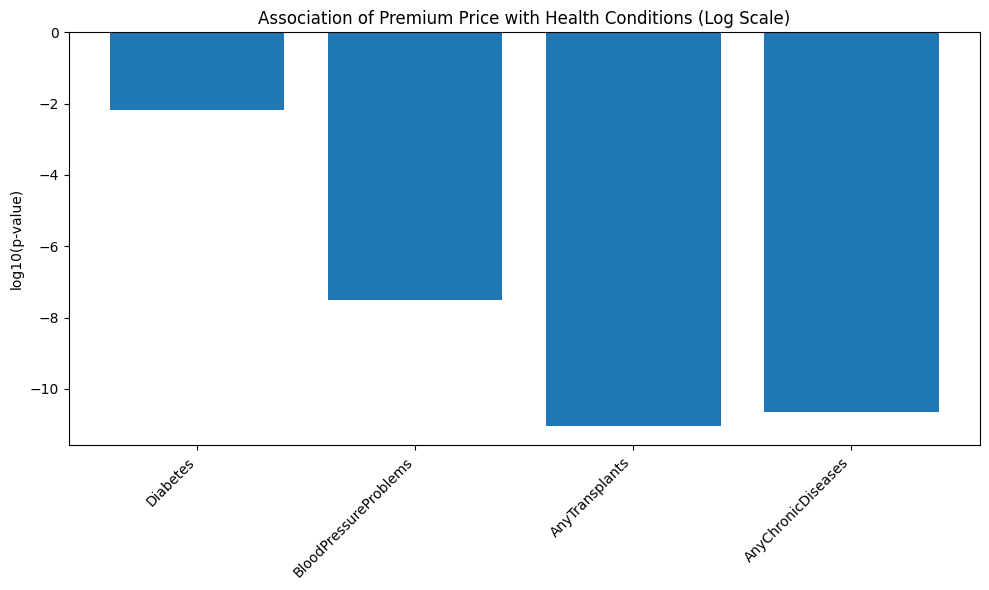

In [ ]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import numpy as np

# Assuming your DataFrame is named 'df'
columns_to_test = ['Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases']

p_values = {}  # Store p-values for each column

for column in columns_to_test:
    # Check for normality using Shapiro-Wilk test
    _, p_value_shapiro = stats.shapiro(df['PremiumPrice'][df[column] == 1])

    if p_value_shapiro > 0.05:
        # Perform ANOVA if data is normally distributed
        model = ols('PremiumPrice ~ ' + column, data=df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        p_value = anova_table['PR(>F)'][0]
        p_values[column] = p_value
        print(f"ANOVA test for {column}: p-value = {p_value}")
    else:
        # Perform Kruskal-Wallis test if data is not normally distributed
        groups = [df['PremiumPrice'][df[column] == 0], df['PremiumPrice'][df[column] == 1]]
        _, p_value = stats.kruskal(*groups)
        p_values[column] = p_value
        print(f"Kruskal-Wallis test for {column}: p-value = {p_value}")

# Plotting p-values in log scale
plt.figure(figsize=(10, 6))
plt.bar(p_values.keys(), np.log10(list(p_values.values())))
plt.ylabel('log10(p-value)')
plt.title('Association of Premium Price with Health Conditions (Log Scale)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## This proves that Chronic and Transplants have significant association with PremiumPrice

In [ ]:
import pandas as pd

# Assuming your DataFrame is named 'df'
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
binary_df = df[binary_cols]

from scipy.stats import chi2_contingency

# Create a dictionary to store p-values
p_values = {}

# Iterate through all combinations of binary columns
for col1 in binary_cols:
    p_values[col1] = {}
    for col2 in binary_cols:
        if col1 != col2:
            # Create a contingency table
            contingency_table = pd.crosstab(binary_df[col1], binary_df[col2])

            # Perform chi-square test
            _, p_value, _, _ = chi2_contingency(contingency_table)

            # Store p-value
            p_values[col1][col2] = p_value

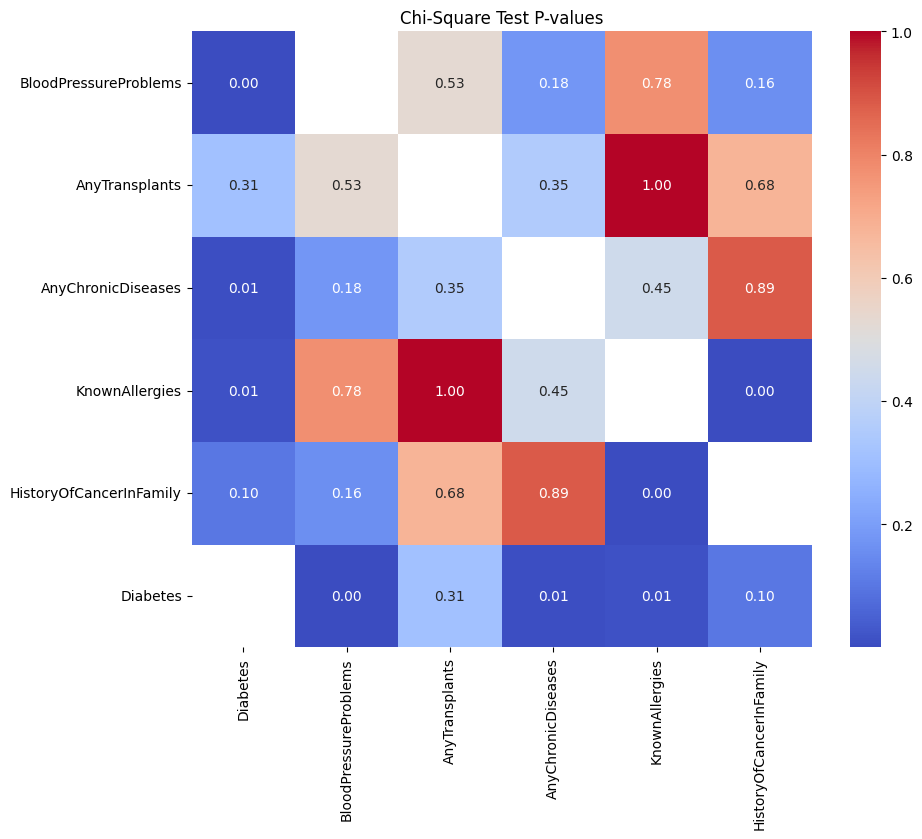

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert p-values dictionary to a DataFrame
p_values_df = pd.DataFrame(p_values)

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(p_values_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Chi-Square Test P-values')
plt.show()

In [ ]:
#Let us perform VIF for all the variables except PremiumPrice
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

In [ ]:
# Assuming your DataFrame is named 'df'
X = df.drop(columns=['PremiumPrice', 'Age_bin'])  # Exclude 'PremiumPrice' and 'Age_bin'
X = pd.get_dummies(X, drop_first=True)  # One-hot encode categorical variables if needed

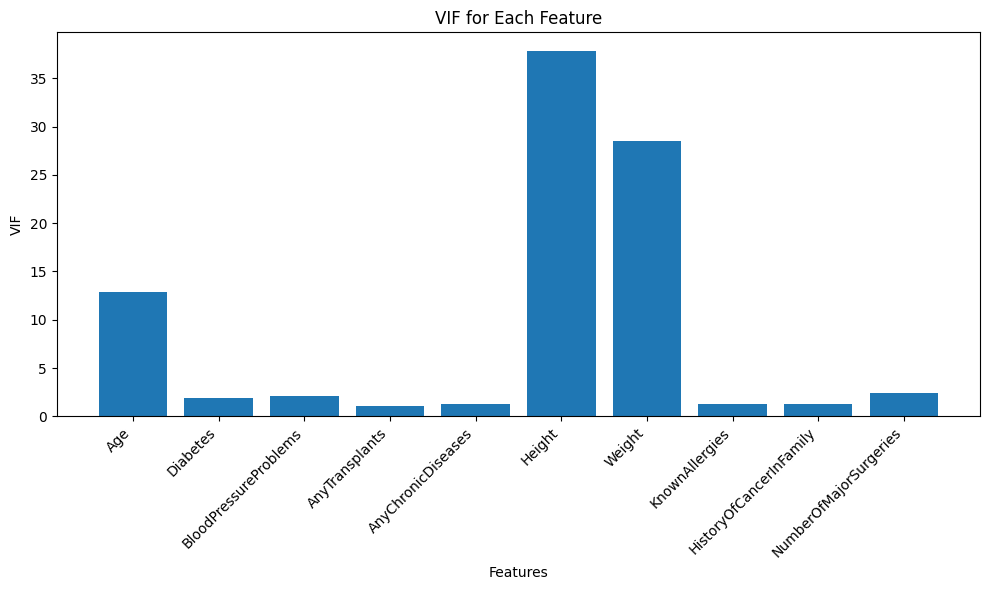

In [ ]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
plt.figure(figsize=(10, 6))
plt.bar(vif_data['feature'], vif_data['VIF'])
plt.xlabel('Features')
plt.ylabel('VIF')
plt.title('VIF for Each Feature')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


## We can see that Height and Weight are correlating which is something that we could as one variable to explain the other

## We will first try using Linear regression in the next Set of notebook for training a model